# Tidal Heating from the Exact Orbit

TidalPy computes tidal heating by expanding the tidal potential into Kaula (1964) modes: products of eccentricity functions $G_{lpq}(e)$ and obliquity functions $F_{lmp}(I)$, each mode forcing the body at one frequency. This benchmark computes the same heating without that expansion, for a viscoelastic body whose Love number depends on frequency.

The independent calculation follows the host along an exact Kepler ellipse (solving Kepler's equation at every step), writes the degree-2 tidal potential it raises in the frame of the rotating body as five time series, one per order $m$,

$$c_m(t) = \left(\frac{a}{r(t)}\right)^3 \overline{Y_{2m}}\big(\theta_\star(t), \phi_\star(t)\big),$$

with $\theta_\star, \phi_\star$ the host's colatitude and longitude seen from the body, and Fourier-transforms them. For a homogeneous body the heating at forcing frequency $\omega$ is proportional to $|\omega|\,(-\mathrm{Im}\,k_2(|\omega|))$ times that frequency's power, so

$$\dot{E} \propto \sum_m \sum_\omega |\omega| \left(-\mathrm{Im}\,k_2(|\omega|)\right) |\hat{c}_m(\omega)|^2 .$$

The Love number at each frequency comes from TidalPy's radial solver on the same body, so the comparison isolates the tidal-potential side: the eccentricity and obliquity functions, the mode bookkeeping, and the collapse to heating. The constant in front of the sum is fixed once, at a low-eccentricity point where every truncation is exact.

The mode sum averages over the argument of periapsis $\omega_p$ (the 1D formula), while a single exact orbit has a definite $\omega_p$, so the exact heating is averaged over $\omega_p$ for the 1D comparison. The 3D path keeps $\omega_p = 0$, and is compared with the exact heating at $\omega_p = 0$.

Reference: Kaula, W. M. (1964), Rev. Geophys. 2, 661.

In [1]:
%matplotlib inline
import math
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y

from TidalPy.constants import G, mass_jupiter
from TidalPy.structures_x import build_world

# A homogeneous, compressible Maxwell body the size of Io, forced by Jupiter.
RADIUS = 1.8216e6            # [m]
DENSITY = 3528.0             # [kg m-3]
SHEAR = 6.0e10               # [Pa]
BULK = 1.2e11                # [Pa]
VISCOSITY = 1.0e17           # [Pa s], so the Maxwell time sits near the forcing periods
MASS = 4.0 / 3.0 * math.pi * RADIUS**3 * DENSITY
HOST = mass_jupiter
N_ORBIT = 2.0 * math.pi / (1.769 * 86400.0)
A_ORBIT = (G * (HOST + MASS) / N_ORBIT**2) ** (1.0 / 3.0)

body = build_world({
    "schema_version": "0.2.0", "name": "maxwell_io", "type": "terrestrial", "radius_m": RADIUS, "mass_kg": MASS,
    "tides": {"global_tidal_model": "rheology", "love_method": "radial_solver", "min_degree_l": 2,
              "max_degree_l": 2, "eccentricity_trunc_lvl": 50, "obliquity_trunc_lvl": "gen"},
    "layers": {"body": {
        "class": "solidliquid", "layer_index": 0, "radius_fraction": 1.0, "is_tidal": True, "is_static": False,
        "material": {"model": "constant", "reference_density_kg_m3": DENSITY,
                     "shear_modulus_static_pa": SHEAR, "bulk_modulus_static_pa": BULK,
                     "shear_viscosity": {"model": "constant", "reference_viscosity_pas": VISCOSITY},
                     "partial_melt": {"model": "off"}},
        "shear_rheology": {"model": "maxwell"}, "bulk_rheology": {"model": "elastic"}}}})
body.solve_eos()

_minus_im_k2 = {}


def minus_im_k2(frequency_ratio):
    "-Im k2 at |omega| = frequency_ratio * n, from TidalPy's radial solver on the same body (cached)."
    key = round(frequency_ratio, 9)
    if key not in _minus_im_k2:
        body.solve_love_numbers(frequency=key * N_ORBIT, degree_l=2, warnings=False)
        _minus_im_k2[key] = -complex(body.love_number_k).imag
    return _minus_im_k2[key]


def exact_orbit_heating(e, inclination, spin_ratio, periapsis=0.0, samples_per_orbit=2048):
    "The sum above for an exact Kepler orbit, up to a constant factor."
    ratio = Fraction(spin_ratio).limit_denominator(12)
    orbits = ratio.denominator                      # the forcing repeats after this many orbits
    mean_anomaly = np.linspace(0.0, 2.0 * math.pi * orbits, samples_per_orbit * orbits, endpoint=False)
    eccentric = mean_anomaly.copy()
    for _ in range(100):
        eccentric -= (eccentric - e * np.sin(eccentric) - mean_anomaly) / (1.0 - e * np.cos(eccentric))
    true = 2.0 * np.arctan2(math.sqrt(1 + e) * np.sin(eccentric / 2), math.sqrt(1 - e) * np.cos(eccentric / 2))
    radius = 1.0 - e * np.cos(eccentric)
    latitude_argument = periapsis + true           # node on the body's x axis
    x = np.cos(latitude_argument)
    y = np.sin(latitude_argument) * math.cos(inclination)
    z = np.sin(latitude_argument) * math.sin(inclination)
    colatitude = np.arccos(np.clip(z, -1.0, 1.0))
    longitude = np.arctan2(y, x) - float(ratio) * mean_anomaly          # body-fixed
    frequencies = np.abs(np.fft.fftfreq(mean_anomaly.size, d=1.0 / mean_anomaly.size)) / orbits   # in units of n
    total = 0.0
    for m in range(-2, 3):
        series = radius**-3 * np.conj(sph_harm_y(2, m, colatitude, longitude))
        power = np.abs(np.fft.fft(series) / series.size) ** 2
        for frequency, p in zip(frequencies, power):
            if frequency > 1e-9 and p > 1e-30:
                total += frequency * minus_im_k2(frequency) * p
    return total


def exact_averaged(e, inclination, spin_ratio):
    "The exact heating averaged over the argument of periapsis (the cross terms go as cos 2 omega_p)."
    return np.mean([exact_orbit_heating(e, inclination, spin_ratio, w)
                    for w in np.linspace(0.0, math.pi, 4, endpoint=False)])


def tidalpy_1d(e, inclination, spin_ratio):
    body.calc_tides(N_ORBIT, spin_ratio * N_ORBIT, e, inclination, A_ORBIT, HOST)
    return body.get_tidal_heating()


def tidalpy_3d(e, inclination, spin_ratio):
    result = body.calc_3d_tides(N_ORBIT, spin_ratio * N_ORBIT, e, inclination, A_ORBIT, HOST,
                                latitude_summed=True, longitude_summed=True, radial_summed=True, radial_slices=32)
    return result["total"]


# The constant in front of the sum, from a low-eccentricity, zero-obliquity, synchronous point.
SCALE = tidalpy_1d(0.001, 0.0, 1.0) / exact_averaged(0.001, 0.0, 1.0)
print(f"Maxwell time {VISCOSITY / SHEAR / 86400:.2f} d, orbital period 1.769 d")

Maxwell time 19.29 d, orbital period 1.769 d


## The 1D Heating Across Eccentricity, Obliquity, and Spin

With the $e^{50}$ tables, the mode sum and the exact orbit agree to about $10^{-13}$ (the precision of the one-point normalization) up to $e = 0.4$, at synchronous and non-synchronous spin, with and without obliquity. Past the tables' range, the `"exact"` eccentricity functions (taken from the exact Kepler orbit, here with a tolerance of $10^{-10}$) agree to about $10^{-12}$ at $e = 0.6$ and $0.8$.

In [2]:
cases = [(0.05, 0.0, 1.0), (0.2, 0.0, 1.0), (0.3, 0.0, 1.0), (0.3, 0.0, 1.5), (0.2, 0.0, 2.5),
         (0.0, 0.3, 1.0), (0.1, 0.3, 1.0), (0.2, 0.8, 1.5), (0.3, 0.2, 0.5), (0.4, 0.0, 1.0)]
# Past the tables' range: the exact eccentricity functions, with a tolerance far below the differences shown.
exact_cases = [(0.6, 0.0, 1.0), (0.6, 0.3, 1.5), (0.8, 0.0, 1.0), (0.8, 0.2, 2.5)]
print(f"{'truncation':>10} {'e':>5} {'obliquity':>10} {'spin/n':>7} {'TidalPy 1D [W]':>15} {'exact [W]':>13} "
      f"{'relative diff.':>15}")
for truncation, case_list in ((50, cases), ("exact", exact_cases)):
    body.set_tide_config(eccentricity_truncation=truncation, eccentricity_exact_tolerance=1.0e-10)
    for e, inclination, spin_ratio in case_list:
        heating = tidalpy_1d(e, inclination, spin_ratio)
        exact = SCALE * exact_averaged(e, inclination, spin_ratio)
        print(f"{str(truncation):>10} {e:5.2f} {inclination:10.2f} {spin_ratio:7.2f} {heating:15.6e} {exact:13.6e} "
              f"{heating / exact - 1:+15.2e}")
body.set_tide_config(eccentricity_truncation=50, eccentricity_exact_tolerance=1.0e-4)

truncation     e  obliquity  spin/n  TidalPy 1D [W]     exact [W]  relative diff.
        50  0.05       0.00    1.00    3.965350e+14  3.965350e+14       -1.09e-13
        50  0.20       0.00    1.00    6.839125e+15  6.839125e+15       -1.08e-13
        50  0.30       0.00    1.00    1.739137e+16  1.739137e+16       -1.09e-13


        50  0.30       0.00    1.50    1.609901e+16  1.609901e+16       -1.08e-13
        50  0.20       0.00    2.50    1.582455e+16  1.582455e+16       -1.09e-13
        50  0.00       0.30    1.00    1.894699e+15  1.894699e+15       -1.09e-13
        50  0.10       0.30    1.00    3.460286e+15  3.460286e+15       -1.10e-13


        50  0.20       0.80    1.50    1.763998e+16  1.763998e+16       -1.09e-13
        50  0.30       0.20    0.50    2.461911e+16  2.461911e+16       -1.08e-13
        50  0.40       0.00    1.00    3.842938e+16  3.842938e+16       -1.09e-13


     exact  0.60       0.00    1.00    2.245284e+17  2.245284e+17       -1.13e-12


     exact  0.60       0.30    1.50    2.230729e+17  2.230729e+17       -1.12e-12


     exact  0.80       0.00    1.00    4.735976e+18  4.735976e+18       -1.33e-12


     exact  0.80       0.20    2.50    4.695682e+18  4.695682e+18       -1.48e-12


## Heating Against Eccentricity

The same comparison across eccentricity at synchronous rotation, for three truncation levels and for the `"exact"` functions at their default tolerance of $10^{-4}$. Each level follows the exact heating until its truncation error sets in; every level errs low.

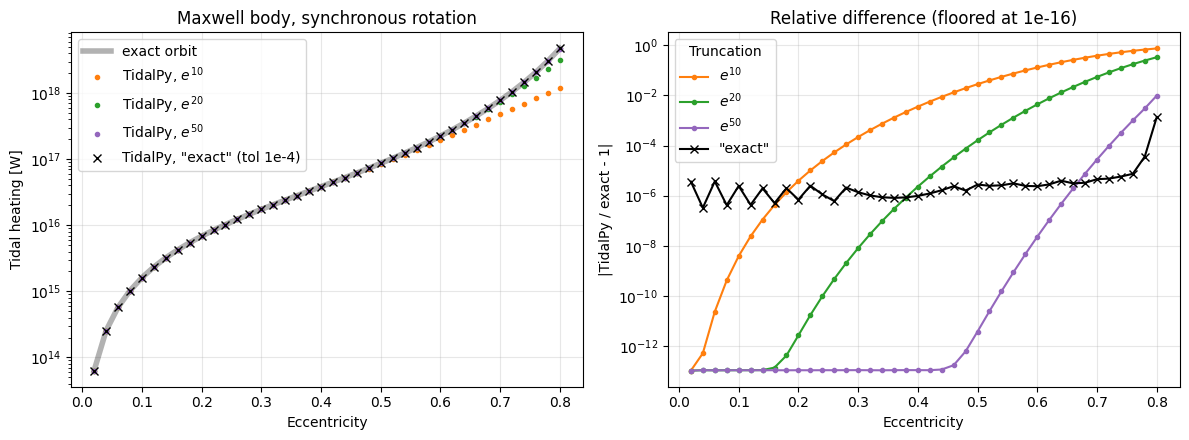

In [3]:
eccentricities = np.linspace(0.02, 0.8, 40)
exact = np.array([SCALE * exact_averaged(e, 0.0, 1.0) for e in eccentricities])
levels = {10: "C1", 20: "C2", 50: "C4", "exact": "k"}
fig, (ax, ax_err) = plt.subplots(1, 2, figsize=(12, 4.5))
ax.semilogy(eccentricities, exact, "k-", lw=4, alpha=0.3, label="exact orbit")
for level, color in levels.items():
    body.set_tide_config(eccentricity_truncation=level, obliquity_truncation=0)
    heating = np.array([tidalpy_1d(e, 0.0, 1.0) for e in eccentricities])
    label = 'TidalPy, "exact" (tol 1e-4)' if level == "exact" else f"TidalPy, $e^{{{level}}}$"
    marker = "x" if level == "exact" else "."
    ax.semilogy(eccentricities, heating, marker, color=color, label=label)
    ax_err.semilogy(eccentricities, np.maximum(np.abs(heating / exact - 1), 1e-16), marker + "-", color=color,
                    label='"exact"' if level == "exact" else f"$e^{{{level}}}$")
body.set_tide_config(eccentricity_truncation=50, obliquity_truncation="gen")
ax.set_xlabel("Eccentricity")
ax.set_ylabel("Tidal heating [W]")
ax.set_title("Maxwell body, synchronous rotation")
ax.legend()
ax_err.set_xlabel("Eccentricity")
ax_err.set_ylabel("|TidalPy / exact - 1|")
ax_err.set_title("Relative difference (floored at 1e-16)")
ax_err.legend(title="Truncation")
for axis in (ax, ax_err):
    axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### A Free Oscillation in the Tail

The `"exact"` functions stay within a few parts in $10^{6}$ up to $e \approx 0.75$, but at $e = 0.8$ they come out 0.13% low at their default tolerance, and a tighter tolerance does not help until it is much tighter. The cause is the body, not the orbit.

This body is solved with inertia (a dynamic layer), so like a bell it has natural vibration frequencies. Its lowest degree-2 one sits near 147 times the orbital frequency, a period of about 17 minutes. A tidal mode that forces the body near that frequency is amplified enormously. When the exact option decides which modes to drop, it assumes the fast, high-$q$ modes matter less and less, which is true away from such a resonance. At $e = 0.8$ the resonant modes lie just past the range the default tolerance keeps, so their heating is missed. The $10^{-10}$ tolerance used in the table above keeps enough modes to include them.

The weight each forcing frequency $\omega = q n$ carries in the heating, $q\,(-\mathrm{Im}\,k_2(q n))$, shows the resonance as a sharp spike (a second, weaker spike near $q = 272$ is the next vibration mode):

weight at q = 1: 4.26e-04; largest weight 6.89e+02 at q = 147 (period 17 min), 1616300 times the q = 1 value


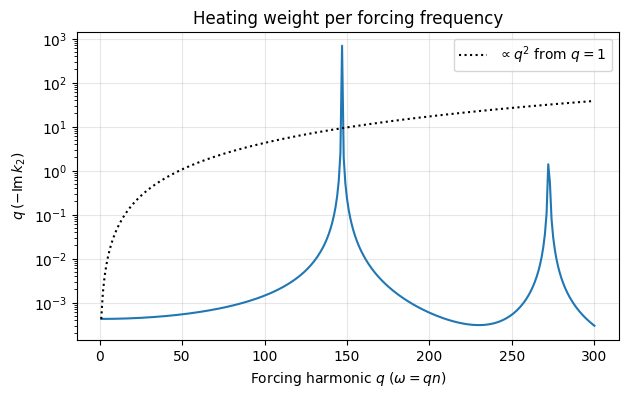

In [4]:
harmonics = np.arange(1, 301)
weights = np.array([q * minus_im_k2(float(q)) for q in harmonics])
peak = harmonics[np.argmax(weights)]
print(f"weight at q = 1: {weights[0]:.2e}; largest weight {weights.max():.2e} at q = {peak} "
      f"(period {1.769 * 24 * 60 / peak:.0f} min), {weights.max() / weights[0]:.0f} times the q = 1 value")

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(harmonics, weights, "C0-")
ax.semilogy(harmonics, weights[0] * harmonics**2, "k:", label=r"$\propto q^2$ from $q = 1$")
ax.set_xlabel(r"Forcing harmonic $q$ ($\omega = q n$)")
ax.set_ylabel(r"$q\,(-\mathrm{Im}\,k_2)$")
ax.set_title("Heating weight per forcing frequency")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## The 3D Heating and the Argument of Periapsis

The volume integral of the 3D heating is compared with the exact heating at $\omega_p = 0$, the geometry the 3D engine assumes, and the 1D heating with the $\omega_p$-averaged one. At nonzero eccentricity and obliquity, modes of the same degree, order, and frequency but different $(p, q)$ interfere in the 3D path, adding a term proportional to $e^2 I^2 \cos 2\omega_p$ that the periapsis-averaged 1D sum does not carry. The exact orbit shows the same term: its heating at $\omega_p = 0$ differs from the average by the same amount as the 3D total differs from the 1D.

In [5]:
print(f"{'e':>5} {'obliquity':>10} {'spin/n':>7} {'3D/1D - 1':>11} {'exact(0)/<exact> - 1':>21} {'3D vs exact(0)':>15}")
for e, inclination, spin_ratio in ((0.05, 0.05, 1.0), (0.05, 0.3, 1.0), (0.2, 0.3, 1.0), (0.2, 0.3, 1.5)):
    one_d = tidalpy_1d(e, inclination, spin_ratio)
    three_d = tidalpy_3d(e, inclination, spin_ratio)
    exact_zero = SCALE * exact_orbit_heating(e, inclination, spin_ratio, 0.0)
    exact_mean = SCALE * exact_averaged(e, inclination, spin_ratio)
    print(f"{e:5.2f} {inclination:10.2f} {spin_ratio:7.2f} {three_d / one_d - 1:+11.3e} "
          f"{exact_zero / exact_mean - 1:+21.3e} {three_d / exact_zero - 1:+15.2e}")

    e  obliquity  spin/n   3D/1D - 1  exact(0)/<exact> - 1  3D vs exact(0)
 0.05       0.05    1.00  -5.819e-04            -5.818e-04       -6.71e-08
 0.05       0.30    1.00  -3.828e-03            -3.828e-03       -6.71e-08


 0.20       0.30    1.00  -1.591e-02            -1.591e-02       -6.71e-08
 0.20       0.30    1.50  -1.267e-03            -1.267e-03       -6.71e-08


## Summary

- For a frequency-dependent (Maxwell) body, TidalPy's mode sum and an independent calculation from the exact orbit give the same tidal heating to $10^{-13}$ up to $e = 0.4$ with the $e^{50}$ tables, and to $10^{-12}$ at $e = 0.8$ with the `"exact"` functions, with and without obliquity, at synchronous and non-synchronous spin. The difference beyond that is the truncation error of the eccentricity tables.
- The tolerance of the `"exact"` functions assumes the fast, high-$q$ modes matter less and less. A body solved with inertia can ring at its natural frequencies, and a tidal mode near one of them can matter a great deal: at $e = 0.8$ here, such a mode just outside the kept range holds 0.13% of the heating. A tighter tolerance includes it.
- The 3D heating's volume integral matches the exact heating for the geometry it assumes (periapsis at the ascending node), including the periapsis-dependent cross terms that the 1D heating averages away. Its remaining difference, $7 \times 10^{-8}$, is the radial quadrature of the 3D integral.